<h1>Pharmaceutical Sales prediction across multiple stores</h1>

<h2>Overview</h2>

<h3>Business Need</h3>

*  You work at Rossmann Pharmaceuticals as a Machine Learning Engineer. The finance team wants to forecast sales in all their stores across several cities six weeks ahead of time. Managers in individual stores rely on their years of experience as well as their personal judgement to forecast sales. 

* The data team identified factors such as promotions, competition, school and state holidays, seasonality, and locality as necessary for predicting the sales across the various stores.
* Your job is to build and serve an end-to-end product that delivers this prediction to analysts in the finance team. 

In [1]:
import warnings
warnings.filterwarnings("ignore")

# loading packages
# basic + dates 
import numpy as np
import pandas as pd

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns # advanced visualisations
%matplotlib inline

import os
import logging
import dvc.api
import mlflow
from mlflow import log_metric, log_param, log_artifacts
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
def log (path,file):
    '''Creating a log file to record the project's logs'''
    #check if file exists
    log_file= os.path.join(path,file)

    if not os.path.isfile(log_file):
        open(log_file,"w+").close()

    console_logging_format = "%(levelname)s %(message)s"
    file_logging_format = "%(levelname)s: %(asctime)s: %(message)s"

    #configure logger
    logging.basicConfig(level=logging.INFO,format=console_logging_format)
    logger=logging.getLogger()

    #file handler for output file
    handler=logging.FileHandler(log_file)

    #set logging level for file
    handler.setLevel(logging.INFO)

    #logging format
    formatter=logging.Formatter(file_logging_format)
    handler.setFormatter(formatter)
    
    #add handlers to logger
    logger.addHandler(handler)

    return logger

In [3]:
path = 'data/train_store.csv'
repo = "../"
version = "'v2'"
# return to normal tag version and print in markdown

data_url = dvc.api.get_url(
    path=path,
    repo=repo,
)

mlflow.set_experiment('Rossmann Pharmeceutical Sales_Forecasting')

if __name__ == '__main__':
    warnings.filterwarnings("ignore")
    np.random.seed(40)
    df = pd.read_csv('../data/train_store.csv', index_col=0)
    mlflow.log_param('data_url', data_url)
    mlflow.log_param('data_version', version)
    mlflow.log_param('input_rows', df.shape[0])
    mlflow.log_param('input_cols', df.shape[1])

In [4]:
#set logger file
#from logs import log
logger=log(path="../logs/",file="rossman_sales.logs")

#Loading datasets
train=pd.read_csv("../data/train.csv",low_memory=False)
test=pd.read_csv("../data/test.csv",low_memory=False)
store=pd.read_csv("../data/store.csv",low_memory=False)

<h2>Data Cleaning and Wrangling</h2>

In [5]:
def get_info(data:pd.DataFrame):
    df = pd.DataFrame()
    df['columns'] = data.columns.to_list()
    df['null'] = data.isnull().sum().to_list()
    df['dtype'] = data.dtypes.to_list()
    print('Dataset shape:',data.shape)
    return df

<h3>Train dataset</h3>

In [6]:
get_info(train)

Dataset shape: (1017209, 9)


,columns,null,dtype
0,Store,0,int64
1,DayOfWeek,0,int64
2,Date,0,object
3,Sales,0,int64
4,Customers,0,int64
5,Open,0,int64
6,Promo,0,int64
7,StateHoliday,0,object
8,SchoolHoliday,0,int64


In [7]:
#we only want information for open Stores since Stores can't make sales if they are closed
train= train[train["Open"] != 0]
#drop Open column since all the remaining data is when Stores are open
train.drop(['Open'],axis=1,inplace=True)
train = train.loc[~(train['Sales'] == 0)]

#creating new features
train['Sales_per_Customer']=train['Sales']/train['Customers']

#date features
train['Date']=pd.to_datetime(train['Date'])
train.set_index('Date',inplace=True)
train['Day']=train.index.day
train['Month']=train.index.month
train['Year']=train.index.year

INFO NumExpr defaulting to 8 threads.


<h3>Test dataset</h3>

In [8]:
get_info(test)

Dataset shape: (41088, 8)


,columns,null,dtype
0,Id,0,int64
1,Store,0,int64
2,DayOfWeek,0,int64
3,Date,0,object
4,Open,11,float64
5,Promo,0,int64
6,StateHoliday,0,object
7,SchoolHoliday,0,int64


In [9]:
test.dropna(subset=['Open'],inplace=True)
print('\n Any more null values?\n',test['Open'].isnull().any())


 Any more null values?
 False


<h3>Store Dataset</h3>

In [10]:
store.sample(2)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
452,453,a,c,75860.0,NaN,NaN,0,NaN,NaN,NaN
525,526,a,a,120.0,NaN,NaN,1,48.0,2011.0,"Mar,Jun,Sept,Dec"


In [11]:
get_info(store)

Dataset shape: (1115, 10)


,columns,null,dtype
0,Store,0,int64
1,StoreType,0,object
2,Assortment,0,object
3,CompetitionDistance,3,float64
4,CompetitionOpenSinceMonth,354,float64
5,CompetitionOpenSinceYear,354,float64
6,Promo2,0,int64
7,Promo2SinceWeek,544,float64
8,Promo2SinceYear,544,float64
9,PromoInterval,544,object


In [12]:
store.Promo2.value_counts()

1    571
0    544
Name: Promo2, dtype: int64

In [13]:
store[store['Promo2']==0 & store['Promo2SinceWeek'].isnull() & store['Promo2SinceYear'].isnull()& store['PromoInterval'].isnull()].shape

(544, 10)

* The stores with Promo2SinceWeek, Promo2SinceYear and PromoInterval as null are the rows where Promo2 is = 0
* We fill Promo2SinceWeek and PromoSinceYear with 0 since they are of numerical type and PromoInterval with "No Promo"
* Fill CompetitionDistance with median and 'CompetitionOpenSinceMonth','CompetitionOpenSinceYear' with mode

In [14]:
#Fillna Promo columns
store['PromoInterval'].fillna("No Promo",inplace = True)
promo_cols = ['Promo2SinceWeek','Promo2SinceYear']
store[promo_cols] = store[promo_cols].fillna(0)

In [15]:
#Fillna competition columns
store['CompetitionDistance'].fillna(store['CompetitionDistance'].median(), inplace = True)

competition_cols = ['CompetitionOpenSinceMonth','CompetitionOpenSinceYear']
store[competition_cols] = store[competition_cols].fillna(store.mode().iloc[0])

In [16]:
print('Are there any more null values? \n',store.isnull().any())

Are there any more null values? 
 Store                        False
StoreType                    False
Assortment                   False
CompetitionDistance          False
CompetitionOpenSinceMonth    False
CompetitionOpenSinceYear     False
Promo2                       False
Promo2SinceWeek              False
Promo2SinceYear              False
PromoInterval                False
dtype: bool


<h2>Exploratory Data Analysis</h2>

In [17]:
#Factor plot
def plot_factor(data,x,y,col,hue):
    sns.factorplot(data=data,x=x,y=y,col=col,hue=hue)
    plt.show()
#Bar plot    
def plot_bar(data,x,y1,y2):
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    sns.barplot(data = data, x = x, y = y1,palette='RdYlBu') 
    plt.title(f'{x} VS {y1}')
    plt.subplot(1,2,2)
    sns.barplot(data = data, x = x, y = y2,palette='RdYlGn')
    plt.title(f'{x} VS {y2}')
    plt.show()
#Histogram
def plot_hist(data,col1,col2):
    sns.histplot(data=data,x=col1,y=col2,bins=30)
    plt.title(f'Distribution of {col1} by {col2}')
    plt.show()

<Figure size 864x432 with 0 Axes>

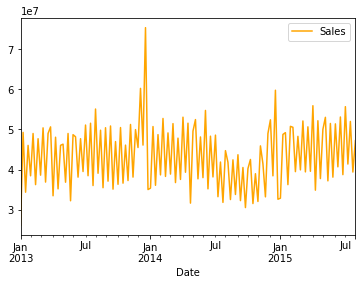

In [18]:
pd.plotting.register_matplotlib_converters()

# preparation: input should be float type
sales = train[['Sales']]
plt.figure(figsize=(12,6))
sales.resample('W').sum().plot(color = 'Orange')
plt.show()

* Because most stores close on Christmas, a few days before the holiday, particularly from 16th December onwards, sales significantly increase and start dropping from 23rd 

We merge Store and Train into one to have all the information in one dataset

In [19]:
train_store = pd.merge(train, store, how = 'inner', on = 'Store')
train_store.groupby(['StoreType'])['Store'].nunique()

StoreType
a    602
b     17
c    148
d    348
Name: Store, dtype: int64

In [20]:
train_store.to_csv("../data/train_store.csv",index=False)

* Customers and Sales have a strong positive correlation 
* Sales and Promo also have a strong positive correlation

**How does promo affect sales? Are the promos attracting more customers?**

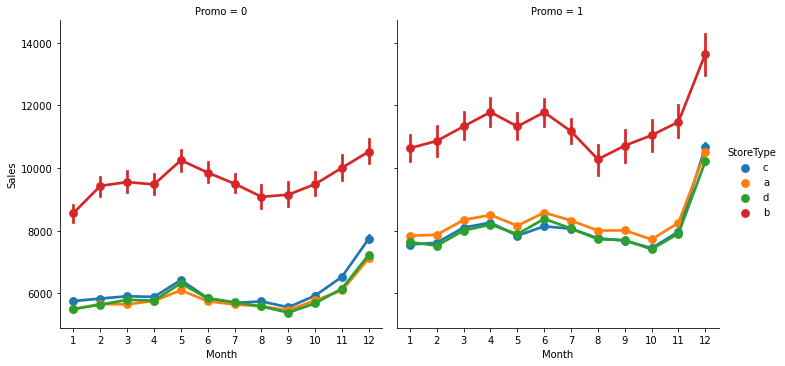

In [21]:
plot_factor(train_store,'Month',"Sales",'Promo','StoreType') 

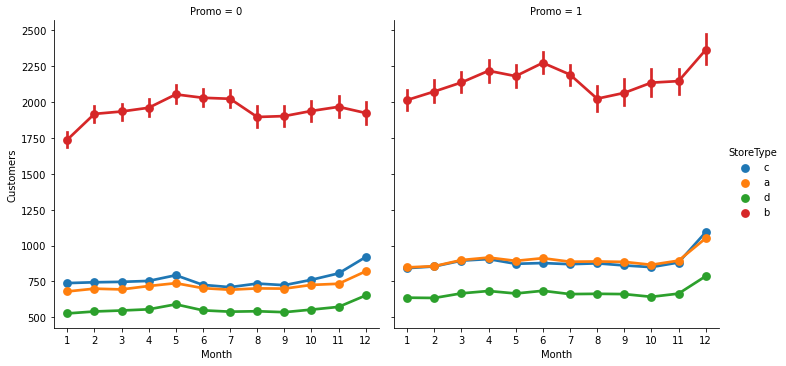

In [22]:
plot_factor(train_store,'Month',"Customers",'Promo','StoreType') 

* Store Type b has the highest sales and customers per month overall, with and without the promo
* However, we can see that promotions lead to higher sales and customers for all store types

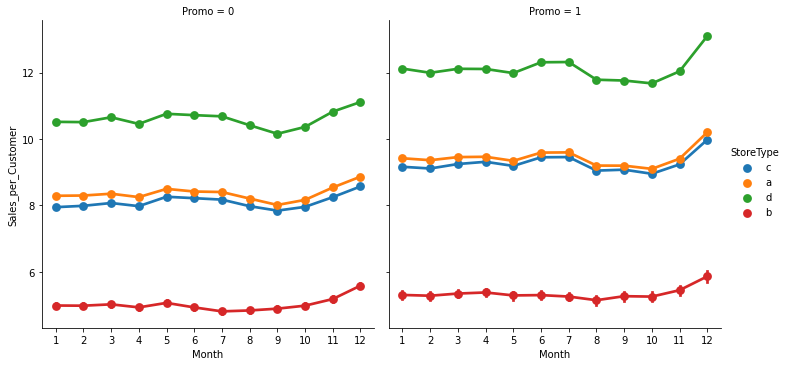

In [23]:
plot_factor(train_store,'Month','Sales_per_Customer','Promo','StoreType')

* StoreType b  has the lowest sales_per_customer, even though it has the highest sales and customers in general
* This means that the store gets lots of customers who by many low-value goods.

**Could the promos be deployed in more effective ways? Which stores should promos be deployed in?**

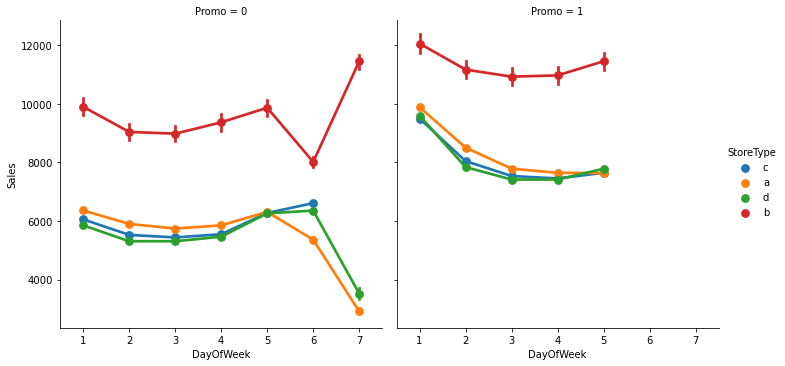

In [24]:
plot_factor(train_store,'DayOfWeek',"Sales",'Promo','StoreType') 

* Store Type a has the most sales on Sundays,
* Store Types b,c,d should try deploying promos on weekends to bump their sales

Store Type a has the highest amount of customers and Sales, followed by Store Type d

**Check how the assortment type affects sales**

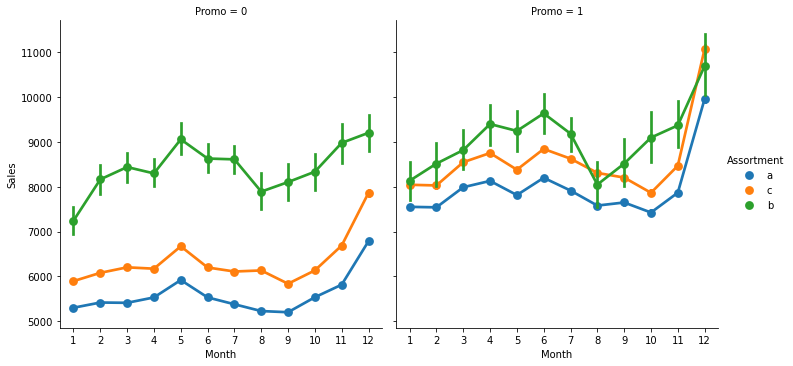

In [25]:
plot_factor(train_store,'Month',"Sales",'Promo','Assortment') 

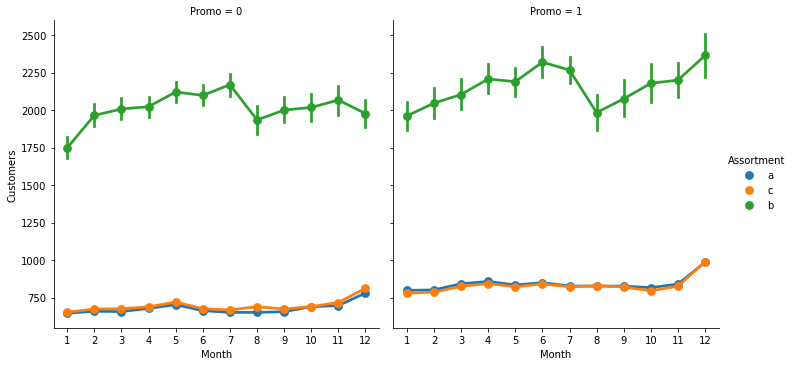

In [26]:
plot_factor(train_store,'Month',"Customers",'Promo','Assortment') 

Assortment a has the highest sales and customers per month.
Promotions lead to higher sales and customers for all assortment types

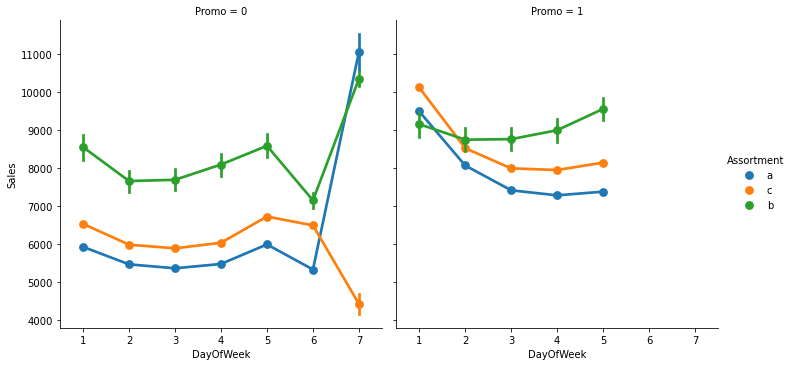

In [27]:
plot_factor(train_store,'DayOfWeek',"Sales",'Promo','Assortment') 

* Assortment A has their highest sales on Sundays, while b and c have no sales on Sundays
* Promotions don't happen on weekends for assortments

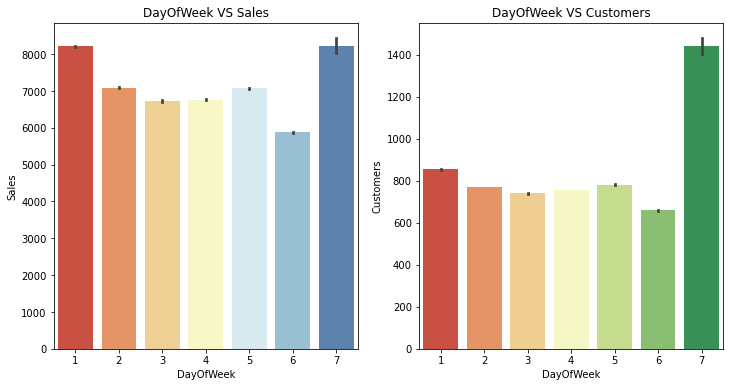

In [28]:
plot_bar(train_store,'DayOfWeek','Sales','Customers')

* Mondays and Sundays have the most sales and customers
* Sundays have the most customers

**How does the distance to the next competitor affect sales?**

In [29]:
pd.set_option('display.float_format',str)
train_store['Decile_rank'] = pd.qcut(train_store['CompetitionDistance'], 5, labels = False) 
train_store.groupby('Decile_rank').agg({'Decile_rank':'count','Sales':'sum'})

,Decile_rank,Sales
Decile_rank,,
0,169487,1287591800
1,169640,1161532905
2,167873,1124487817
3,168853,1148973176
4,168485,1150594925


<AxesSubplot:xlabel='CompetitionDistance', ylabel='Density'>

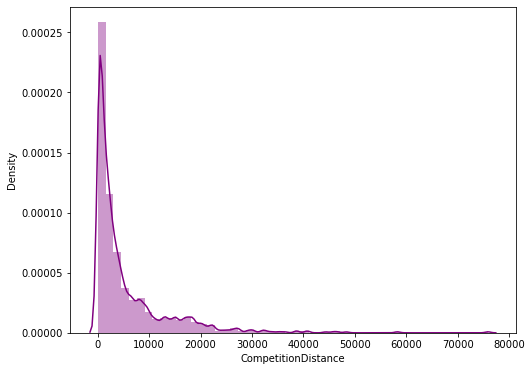

In [30]:
#CompetitionDistance
fig = plt.figure(figsize = (8,6))
sns.distplot(train_store.CompetitionDistance, color = 'purple')

* The total number of sales across the decile classes is somewhat balanced, apart from the first class which has a bit higher values compared to the rest. 
* The stores could be located in densely populated areas hence, distance to nearest competitor has a small influence
* Most stores are located around 5km from competitors

<h2>Machine Learning </h2>
<h3>Feature Selection</h3>

* Ordinal Variable: Finite variable set of discrete values with a ranked ordering between the values. This include:
    * PromoSinceYear,CompetitionOpenSinceYear, Decile_rank(already ranked), Year -> Label encoding
* Nominal Variable: Finite variable set of discrete values with no relationship between values. 
    * Day Of Week, Month, StateHoliday, StoreType, Assortment, CompetitionOpenSinceMonth. PromoSinceWeek, PromoInterval,Day Month -> One hot encoding for features like StateHoliday,StoreType,Assortment and Frequency encoding for the rest

In [31]:
train_store.drop(['Store'],axis=1,inplace=True)

In [32]:
train_store.T.apply(lambda x: x.nunique(),axis=1)

DayOfWeek                         7
Sales                         21733
Customers                      4083
Promo                             2
StateHoliday                      4
SchoolHoliday                     2
Sales_per_Customer           651456
Day                              31
Month                            12
Year                              3
StoreType                         4
Assortment                        3
CompetitionDistance             655
CompetitionOpenSinceMonth        12
CompetitionOpenSinceYear         23
Promo2                            2
Promo2SinceWeek                  25
Promo2SinceYear                   8
PromoInterval                     4
Decile_rank                       5
dtype: int64

In [33]:
train_store.columns

Index(['DayOfWeek', 'Sales', 'Customers', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'Sales_per_Customer', 'Day', 'Month', 'Year',
       'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Decile_rank'],
      dtype='object')

In [34]:
#label encoding ordinal columns
le = LabelEncoder()
ord_columns = ['Promo2SinceYear','CompetitionOpenSinceYear','Year']

ord_df = pd.DataFrame()
for i in ord_columns:
    ord_df[i] = le.fit_transform(train_store[i].astype(str))

#one hot encode nominal columns with few unique variables
one_hot = OneHotEncoder()
one_cols = ['StateHoliday','StoreType','Assortment','PromoInterval']
dummies = pd.get_dummies(train_store[one_cols])


In [35]:
#list of columns in the train_store dataset
cols_list = train_store.columns.to_list()
#list of numerical columns
num_cols = ['Sales','Customers','Sales_per_Customer','CompetitionDistance','Decile_rank','Promo','Promo2','SchoolHoliday']
#the remaining columns are nominal
nom_cols = list(set(cols_list) - set(ord_columns) -set(one_cols) - set(num_cols))
nom_cols

['DayOfWeek', 'CompetitionOpenSinceMonth', 'Promo2SinceWeek', 'Day', 'Month']

In [36]:
#frequency encode the rest of the nominal variables
nom_df = pd.DataFrame()
for i in nom_cols:
    enc_nom = (train_store.groupby(i).size()) / len(train_store)
    nom_df[f'nom_{i}'] = train_store[i].apply(lambda x : enc_nom[x])

In [37]:
train_store[["Sales"]].shape

(844338, 1)

In [38]:
#standardise numerical columns
min_max = MinMaxScaler()

num_df = train_store.loc[:,num_cols]
num_df[num_cols] = min_max.fit_transform(num_df[num_cols])

In [39]:
clean_df = pd.concat([num_df.reset_index(drop=True),nom_df.reset_index(drop=True),
ord_df.reset_index(drop=True),dummies.reset_index(drop=True)],axis=1,ignore_index=True)

clean_cols = [list(num_df.columns),list(nom_df.columns),list(ord_df.columns),list(dummies.columns)]

flatten = lambda nested_lists: [item for sublist in nested_lists for item in sublist]

clean_df.columns = flatten(clean_cols)
clean_df.to_csv("../data/clean_data.csv")
clean_df.sample(3)

,Sales,Customers,Sales_per_Customer,CompetitionDistance,Decile_rank,Promo,Promo2,SchoolHoliday,nom_DayOfWeek,nom_CompetitionOpenSinceMonth,...,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",PromoInterval_No Promo
743659,0.21219130225274063,0.11626016260162603,0.12014042108442749,0.0061972573839662445,0.0,0.0,1.0,0.0,0.17060940050074733,0.038915694899436006,...,0,1,0,0,0,1,0,1,0,0
482077,0.16438983255029516,0.07208672086720867,0.16028759393069072,0.133834388185654,1.0,1.0,0.0,0.0,0.17049451759840253,0.08293834933403448,...,0,0,1,1,0,0,0,0,0,1
739647,0.16537766534152512,0.07479674796747968,0.15416169565316493,0.05801687763713081,0.75,1.0,0.0,0.0,0.16419135464707263,0.43118632585528543,...,0,0,0,1,0,0,0,0,0,1


<AxesSubplot:>

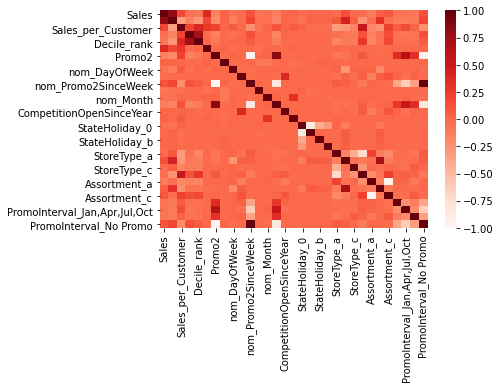

In [40]:
corr=clean_df.corr()
sns.heatmap(corr, cmap="Reds")

In [41]:
X = clean_df.loc[:,clean_df.columns != "Sales"][:100000]
y = clean_df["Sales"][:100000].values
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
X_train.shape

(80000, 30)

In [42]:
rand = RandomForestRegressor(max_depth=10,random_state=2)
rand.fit(X_train,y_train)
rand_pred = rand.predict(X_test)

In [43]:
dtree = DecisionTreeRegressor(splitter='random', max_depth=10, random_state=2)
dtree.fit(X_train,y_train)
dtree_pred = dtree.predict(X_test)

In [44]:
sgd = SGDRegressor(eta0=0.1,fit_intercept=False,shuffle=False,learning_rate='adaptive',random_state=2)
sgd.fit(X_train,y_train)
sgd_pred = sgd.predict(X_test)

In [45]:
#loss function
def rmse_function(actual,pred):
    rmse=np.sqrt(mean_squared_error(actual,pred))
    return rmse
def mae_function(actual,pred):
    mae=mean_absolute_error(actual,pred)
    return mae

In [46]:
rmse_function(y_test,rand_pred)

0.003314867127981457

In [47]:
rmse_function(y_test,dtree_pred)

0.020874623037030703

In [48]:
rmse_function(y_test,sgd_pred)

0.07416132221113245

In [49]:
mlflow.log_metric('RandomForest_RMSE',rmse_function(y_test,rand_pred))
mlflow.log_metric('RandomForest_MAE',mae_function(y_test,rand_pred))

mlflow.log_metric('DecisionTree_RMSE',rmse_function(y_test,dtree_pred))
mlflow.log_metric('DecisionTree_MAE',mae_function(y_test,dtree_pred))

mlflow.log_metric('SGDRegression_RMSE',rmse_function(y_test,sgd_pred))
mlflow.log_metric('SGDRegression_MAE',mae_function(y_test,sgd_pred))